# Spatial mismatch diagnostics

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import dask.dataframe as dd
import os
from glob import glob

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

import matplotlib.transforms as mtransforms

crs = ccrs.PlateCarree()

import histlib.matchup as match
from histlib.diagnosis import (
    build_matchup_dataframe,
    synthetic_figure,
    path_csv,
    put_fig_letter,
    build_diagnostic,
)
from histlib.cstes import labels, zarr_dir, matchup_dir, c0, U

U2 = U**2
zarr_dir = zarr_dir + "_ok"

/home1/datahome/mdemol/.miniconda3/envs/histenv2/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv2/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


__________
___________
# Compute mean

In [2]:
comb_av_d = {
    "acc": "drifter_acc_x_25",
    "cor": "drifter_coriolis_x_25",
    "ggx": "aviso_drifter_ggx_adt",
    "wd": "es_cstrio_z15_drifter_wd_x",
}
comb_av_al = {
    "acc": "drifter_acc_x_25",
    "cor": "drifter_coriolis_x_25",
    "ggx": "aviso_alti_ggx_adt",
    "wd": "es_cstrio_z15_drifter_wd_x",
}
comb_alg = {
    "acc": "drifter_acc_x_25",
    "cor": "drifter_coriolis_x_25",
    "ggx": "alti_ggx_adt_filtered_ocean_tide_internal_tide",
    "wd": "es_cstrio_z15_drifter_wd_x",
}


dad = (
    pd.read_csv(
        os.path.join(
            zarr_dir,
            "analysis_files",
            "dist_mean___" + "__".join([comb_av_d[key] for key in comb_av_d]) + ".csv",
        )
    )
    .set_index("distbin")
    .to_xarray()
)
daa = (
    pd.read_csv(
        os.path.join(
            zarr_dir,
            "analysis_files",
            "dist_mean___"
            + "__".join([comb_av_al[key] for key in comb_av_al])
            + ".csv",
        )
    )
    .set_index("distbin")
    .to_xarray()
)
dl = (
    pd.read_csv(
        os.path.join(
            zarr_dir,
            "analysis_files",
            "dist_mean___" + "__".join([comb_alg[key] for key in comb_alg]) + ".csv",
        )
    )
    .set_index("distbin")
    .to_xarray()
)


def center_distbin(df):
    dl = df.distbin.diff("distbin").mean() / 1e3
    df["distbin"] = df["distbin"] / 1e3 + dl / 2
    return df


def prepared(ds):
    ds_ = center_distbin(ds).set_coords(["obs", "nb_coloc_bin", "alti___distance"]) / U2
    ds_.nb_coloc_bin.attrs["long_name"] = "Number of colocalizations per bin"
    ds_.distbin.attrs["long_name"] = "Spatial colocalization mismatch $\Delta X$"
    ds_.distbin.attrs["units"] = "km"
    return ds_


dad = prepared(dad)
daa = prepared(daa)
dl = prepared(dl)

__________
___________
# Distribution

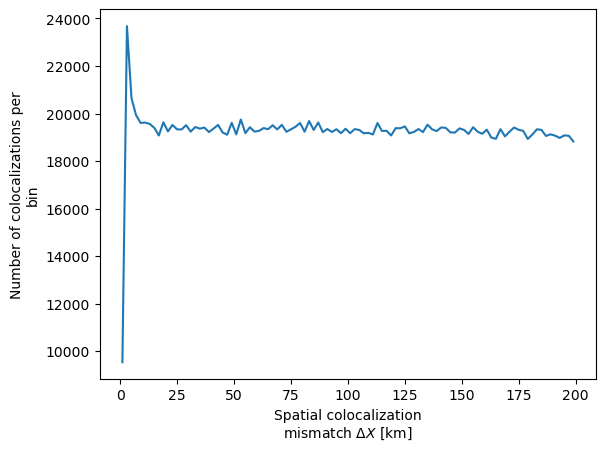

In [3]:
dl.nb_coloc_bin.plot()

In [4]:
dl.nb_coloc_bin.mean()

<xarray.DataArray 'nb_coloc_bin' ()>
array(19267.78)

__________
___________
# Figures

In [3]:
# get handles, labels for next figure
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(1, 1))
l = {
    "acc": "Lagrangian acceleration",
    "cor": "Coriolis acceleration",
    "ggx": "Pressure gradient term",
    "wd": "Wind term",
}
for v in ["acc", "cor", "ggx", "wd"]:
    dl["E_" + v].plot(color=c0[v], ax=ax, label=l[v])
plt.close(fig)
handles_, labels_ = ax.get_legend_handles_labels()


fig, ax = plt.subplots(1, 1, sharex=True, figsize=(1, 1))
dl["E_" + v].plot(ls="dashed", color="k", ax=ax, label="Along-track max.")
dl["E_" + v].plot(ls=":", color="k", ax=ax, label="drifter-matchup AVISO max.")
plt.close(fig)
handles__, labels__ = ax.get_legend_handles_labels()


# dummy item
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(1, 1))
dl["E_" + v].plot(ls="", color="w", ax=ax, label="  ")
plt.close(fig)
handles_dummy, labels_dummy = ax.get_legend_handles_labels()


# born_co = ((dsd['exc_ggrad_co__25__adt_filtered_ocean_tide_internal_tide__es_cstrio_z15__drifter_x'] + dsd['alti_ggx_adt_filtered_ocean_tide_internal_tide'])*dsd['nb_coloc']).sum()/(dsd['nb_coloc']).sum()
# born_co = xr.full_like(dsd['sum_'+id_co], born_co)
# born_aviso = ((dsd['exc_ggrad_aviso__25__adt__es_cstrio_z15__alti_x'] + dsd['aviso_alti_ggx_adt'])*dsd['nb_coloc']).sum()/(dsd['nb_coloc']).sum()
# born_aviso = xr.full_like(dsd['sum_'+id_co], born_aviso)#

In [4]:
# Bornes S-x + A
comb_av_d = {
    "acc": "drifter_acc_x_25",
    "cor": "drifter_coriolis_x_25",
    "ggx": "aviso_drifter_ggx_adt",
    "wd": "es_cstrio_z15_drifter_wd_x",
}
comb_av_al = {
    "acc": "drifter_acc_x_25",
    "cor": "drifter_coriolis_x_25",
    "ggx": "aviso_alti_ggx_adt",
    "wd": "es_cstrio_z15_drifter_wd_x",
}
comb_alg = {
    "acc": "drifter_acc_x_25",
    "cor": "drifter_coriolis_x_25",
    "ggx": "alti_ggx_adt_filtered_ocean_tide_internal_tide",
    "wd": "es_cstrio_z15_drifter_wd_x",
}

comb = comb_alg
path = path_csv(comb, "both", True, 25e3, 30 * 60)
dfalg = pd.read_csv(path)

comb = comb_av_al
path = path_csv(comb, "both", True, 25e3, 30 * 60)
dfal = pd.read_csv(path)


def born(df):
    df["exc_ggx"] = df[["acc", "cor", "wd"]].sum(axis=1)
    return (df["exc_ggx"] ** 2 + df["GGX"]).mean()


born_co = born(dfalg)
born_av = born(dfal)

born_co = xr.full_like(dl["S"], born_co) / U2
born_av = xr.full_like(dl["S"], born_av) / U2

In [5]:
def exp_decay(dx, dx_constant, amplitude, cst):
    return np.exp(-dx / dx_constant) * amplitude + cst


fit_cor_alg = dl.X_cor_ggx.curvefit("distbin", exp_decay)
fit_acc_alg = dl.X_acc_ggx.curvefit("distbin", exp_decay)
fit_cor_av = daa.X_cor_ggx.curvefit("distbin", exp_decay)
fit_acc_av = daa.X_acc_ggx.curvefit("distbin", exp_decay)
# fit_cor_wd_alti = cor_wd_alti.curvefit("distbin", exp_decay)

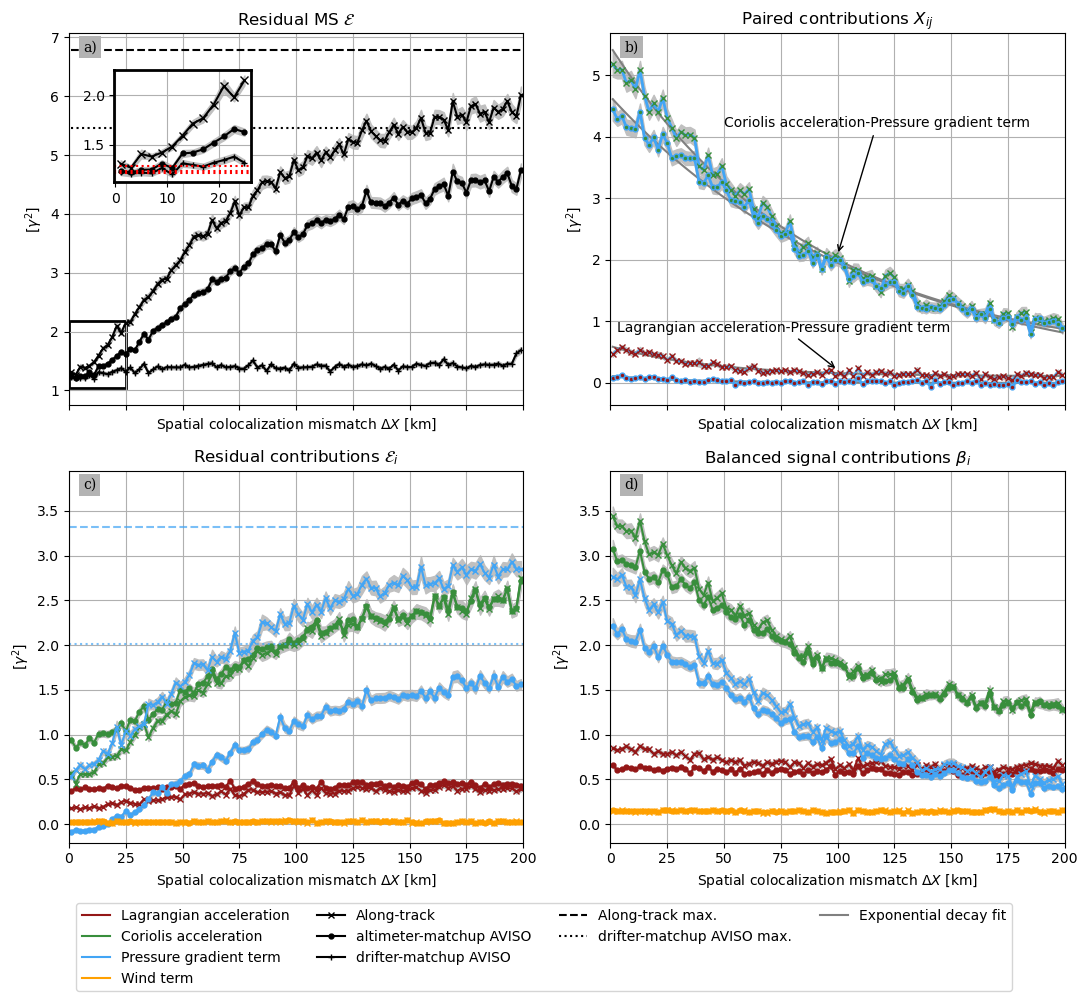

In [14]:
def plot_error(df, v, ax):
    ax.fill_between(
        df.distbin, df[v] - df["be__" + v], df[v] + df["be__" + v], color="silver"
    )


fig, axs = plt.subplots(2, 2, sharex=True, figsize=(11, 10), frameon=False)
axs = axs.flatten()

# plot param
m = 3.5  # markersize
a = 0.7
ins_ax_box = [0.1, 0.60, 0.3, 0.3]  # [x0,y0,xlen, ylen]
import matplotlib.patches as patches

ax = axs[0]
dl.S.plot(
    label="Along-track", ax=ax, c="k", marker="x", markeredgewidth=1, markersize=m + 1
)
daa.S.plot(label="altimeter-matchup AVISO", ax=ax, c="k", marker="o", markersize=m)
dad.S.plot(
    label="drifter-matchup AVISO",
    ax=ax,
    c="k",
    marker="+",
    markersize=m + 1,
)
born_co.plot(ax=ax, color="k", ls="dashed")
born_av.plot(ax=ax, color="k", ls=":")
plot_error(dl, "S", ax)
plot_error(daa, "S", ax)
plot_error(dad, "S", ax)

ax.set_xlabel("Spatial colocalization mismatch $\Delta X$ [km]")
ax.set_ylabel(r"$[\gamma^2]$")
ax.set_title(r"Residual MS $\mathcal{E}$")
put_fig_letter(fig, ax, "a")
handles0, labels0 = ax.get_legend_handles_labels()

# ZOOM
rect = patches.Rectangle(
    (0, 1e-10 / U2), 25, 1.1e-10 / U2, linewidth=2, edgecolor="k", facecolor="none"
)
ax.add_patch(rect)
ins = ax.inset_axes(ins_ax_box)
dl.sel(distbin=slice(0, 25)).S.plot(label="Along-track", ax=ins, c="k", marker="x")
daa.sel(distbin=slice(0, 25)).S.plot(
    label="altimeter-matchup AVISO", ax=ins, c="k", marker="o", markersize=m
)
dad.sel(distbin=slice(0, 25)).S.plot(
    label="drifter-matchup AVISO",
    ax=ins,
    c="k",
    marker="+",
    markersize=m + 1,
)
plot_error(dl.sel(distbin=slice(0, 25)), "S", ins)
plot_error(daa.sel(distbin=slice(0, 25)), "S", ins)
plot_error(dad.sel(distbin=slice(0, 25)), "S", ins)

# ins.plot(dl.S.isel(distbin=0).distbin, dl.S.isel(distbin=0), color='r', marker='x', markeredgewidth = 2,markersize=m+1)
# ins.plot(daa.S.isel(distbin=0).distbin,daa.S.isel(distbin=0), color='r', marker='o', markersize=m)
# ins.plot(dad.S.isel(distbin=0).distbin, dad.S.isel(distbin=0), color='r', marker='s', markersize=m,)

ins.axhline(dl.S.isel(distbin=[0, 1]).mean(), color="r", ls=":")
ins.axhline(daa.S.isel(distbin=[0, 1]).mean(), color="r", ls=":")
ins.axhline(dad.S.isel(distbin=[0, 1]).mean(), color="r", ls=":")


ins.grid()
ins.spines["bottom"].set_color("k")
ins.spines["top"].set_color("k")
ins.spines["left"].set_color("k")
ins.spines["right"].set_color("k")
ins.spines["bottom"].set_linewidth(2)
ins.spines["top"].set_linewidth(2)
ins.spines["left"].set_linewidth(2)
ins.spines["right"].set_linewidth(2)
ins.set_xlabel("")
ins.set_ylabel("")
# ins.set_ylim(1e-10, 2.1e-10)
# ax.annotate('',xy=(12.5,2.1e-10),xytext=(25,4.25e-10),arrowprops={'arrowstyle':'-', 'color':'k', 'linewidth':2})

ax = axs[1]

exp_decay(dl.distbin, *fit_cor_alg.curvefit_coefficients).plot(
    c="grey", label="Exponential decay fit", ax=ax
)
exp_decay(dl.distbin, *fit_acc_alg.curvefit_coefficients).plot(c="grey", ax=ax)
exp_decay(daa.distbin, *fit_cor_av.curvefit_coefficients).plot(c="grey", ax=ax)
exp_decay(daa.distbin, *fit_acc_av.curvefit_coefficients).plot(c="grey", ax=ax)
dl.X_cor_ggx.plot(
    c=c0["ggx"],
    marker="x",
    markeredgewidth=1,
    markeredgecolor=c0["cor"],
    markersize=m + 1,
    lw=2,
    ax=ax,
)  # ,label= 'Coriolis acceleration - Pressure gradient estimated from along-track altimetry')
dl.X_acc_ggx.plot(
    c=c0["ggx"],
    marker="x",
    markeredgewidth=1,
    markeredgecolor=c0["acc"],
    markersize=m + 1,
    ax=ax,
)  # , label= 'Lagrangian acceleration - Pressure gradient estimated from along-track altimetry')
daa.X_cor_ggx.plot(
    c=c0["ggx"], marker="o", markerfacecolor=c0["cor"], markersize=m, lw=2, ax=ax
)  # , label= 'Coriolis acceleration - Pressure gradient estimated from AVISO altimetry at along-track matchup')
daa.X_acc_ggx.plot(
    c=c0["ggx"], marker="o", markerfacecolor=c0["acc"], markersize=m, lw=2, ax=ax
)  # , label= 'Lagrangian acceleration - Pressure gradient estimated from AVISO altimetry at along-track matchup')
plot_error(dl, "X_cor_ggx", ax)
plot_error(dl, "X_acc_ggx", ax)
plot_error(daa, "X_cor_ggx", ax)
plot_error(daa, "X_acc_ggx", ax)

put_fig_letter(fig, ax, "b")
handles_exp, labels_exp = ax.get_legend_handles_labels()


ax.set_xlabel("Spatial colocalization mismatch $\Delta X$ [km]")
ax.set_ylabel(r"$[\gamma^2]$")
ax.set_title(r"Paired contributions $X_{ij}$")
handles1, labels1 = ax.get_legend_handles_labels()

ax.annotate(
    "Coriolis acceleration-Pressure gradient term",
    xy=(100, 2e-10 / U2),
    xytext=(50, 4e-10 / U2),
    arrowprops=dict(arrowstyle="->"),
)
ax.annotate(
    "Lagrangian acceleration-Pressure gradient term",
    xy=(100, 0.2e-10 / U2),
    xytext=(3, 0.8e-10 / U2),
    arrowprops=dict(arrowstyle="->"),
)
ax = axs[2]

for v in ["acc", "cor", "ggx", "wd"]:
    dl["E_" + v].plot(
        label="Along Track " + v,
        color=c0[v],
        marker="x",
        markeredgewidth=1,
        markersize=m + 1,
        ax=ax,
    )
    plot_error(dl, "E_" + v, ax)
    daa["E_" + v].plot(
        label="drifter-matchup AVISO " + v, color=c0[v], marker="o", markersize=m, ax=ax
    )
    plot_error(daa, "E_" + v, ax)
    if v == "ggx":
        ax.axhline(dl["GGX"].mean(), color=c0[v], ls="--", alpha=a)
        ax.axhline(daa["GGX"].mean(), color=c0[v], ls=":", alpha=a)
# ax.legend(ncol = 2, bbox_to_anchor=(0, -0.7), loc='lower left')
ax.set_xlim(0, 200)
ax.set_ylim(-0.2e-10 / U2, 3.8e-10 / U2)
ax.set_xlabel("Spatial colocalization mismatch $\Delta X$ [km]")
ax.set_ylabel(r"$[\gamma^2]$")
ax.set_title(r"Residual contributions $\mathcal{E}_i$")
put_fig_letter(fig, ax, "c")

ax = axs[3]

for v in ["acc", "cor", "ggx", "wd"]:
    dl["B_" + v].plot(
        label="Along Track " + v,
        color=c0[v],
        marker="x",
        markeredgewidth=1,
        markersize=m + 1,
        ax=ax,
    )
    plot_error(dl, "B_" + v, ax)
    daa["B_" + v].plot(
        label=" drifter-matchup AVISO " + v,
        color=c0[v],
        marker="o",
        markersize=m,
        ax=ax,
    )
    plot_error(daa, "B_" + v, ax)

# ax.legend(ncol = 2, bbox_to_anchor=(0, -0.7), loc='lower left')
ax.set_xlim(0, 200)
ax.set_ylim(-0.2e-10 / U2, 3.8e-10 / U2)
ax.set_xlabel("Spatial colocalization mismatch $\Delta X$ [km]")
ax.set_ylabel(r"$[\gamma^2]$")
ax.set_title(r"Balanced signal contributions $\beta_i$")

put_fig_letter(fig, ax, "d")


for ax in axs:
    ax.grid()
handles, labels = (
    handles_
    + handles0
    + handles_dummy
    + handles__
    + 2 * handles_dummy
    + handles_exp
    + 3 * handles_dummy,
    labels_
    + labels0
    + labels_dummy
    + labels__
    + 2 * labels_dummy
    + labels_exp
    + 3 * labels_dummy,
)
fig.legend(handles, labels, ncols=4, loc="lower center")
fig.tight_layout(rect=[0, 0.09, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

# fig.savefig('../images_all/dist_total.png',bbox_inches='tight',   dpi=300)

__________
___________
# Colocalizations errors estimation

In [40]:
# 25 km dataset

In [67]:
# 25 km dataset


def global_stast(df):
    from histlib.cstes import U

    # Mean
    mean = df.mean().compute()
    nb_coloc = len(df)
    mean["nb_coloc"] = nb_coloc

    # Central limit theorem
    errors = (2 * df.std() / np.sqrt(nb_coloc)).compute()

    df = pd.DataFrame([mean, errors], index=["value", "errors"]).transpose() / (U**2)

    df["percentage"] = df.value / df.value.sigma * 100
    df["percentage_erros"] = df.percentage * np.sqrt(
        (df.errors / df.value) ** 2 + (df.errors.sigma / df.value.sigma) ** 2
    )

    return df


DL, DT = 25e3, 30 * 60
comb_alg = {
    "acc": "drifter_acc_x_25",
    "cor": "drifter_coriolis_x_25",
    "ggx": "alti_ggx_adt_filtered_ocean_tide_internal_tide",
    "wd": "es_cstrio_z15_drifter_wd_x",
}
df_alg = dd.read_csv(path_csv(comb_alg, "both", True, DL, DT)).repartition(
    npartitions=10
)
dfalg = global_stast(df_alg)
dfalg

,value,errors,percentage,percentage_erros
obs,5.750261e+14,2.090045e+12,6.858768e+15,7.755345e+13
acc,3.906361e+02,4.228043e+02,4.659411e+03,5.043352e+03
cor,-2.229967e+02,8.182263e+02,-2.659850e+03,-9.759641e+03
drogue_status,1.039111e+10,0.000000e+00,1.239426e+11,1.327064e+09
ggx,1.970851e+03,7.609455e+02,2.350782e+04,9.079858e+03
wd,-1.304171e+02,1.715550e+02,-1.555583e+03,-2.046334e+03
alti___distance,1.326366e+14,2.974264e+11,1.582056e+15,1.730673e+13
alti___time_difference,9.049134e+12,2.209272e+10,1.079358e+14,1.185341e+12
lat,4.097575e+10,1.680418e+09,4.887485e+11,2.071548e+10
lon,-1.165983e+11,4.384160e+09,-1.390756e+12,-5.437201e+10


In [76]:
dl_ = dl.sel(distbin=slice(0, 4)).mean()

In [77]:
vars = ["S", "E_acc", "E_cor", "E_ggx", "E_wd"]
for v in vars:
    coloc_error = np.round(dfalg.loc[v].value - dl_[v].values, 4)
    S_perc = np.round(
        (dfalg.loc[v].value - dl_[v].values) / dfalg.loc["S"].value * 100, 2
    )
    print(f" {v} : {coloc_error} so {S_perc}% of the residual MS")

 S : 0.3511 so 21.43% of the residual MS
 E_acc : 0.0206 so 1.26% of the residual MS
 E_cor : 0.1404 so 8.57% of the residual MS
 E_ggx : 0.1941 so 11.85% of the residual MS
 E_wd : -0.004 so -0.24% of the residual MS
